In [15]:
%matplotlib inline

from torch_geometric.datasets import TUDataset
from torch_geometric.utils import to_networkx

import networkx as nx
import matplotlib.pyplot as plt

import numpy as np

from rdkit import Chem

dataset = TUDataset("./datasets","MUTAG",use_node_attr=True,use_edge_attr=True)
print(dataset)
graphs = [to_networkx(g, node_attrs=["x"],edge_attrs=["edge_attr"],to_undirected=True, remove_self_loops=True) for g in dataset]
y = dataset.y


MUTAG(188)


In [16]:
#load Acyclic dataset from gklearn

from gklearn.dataset import DataLoader

dataset = DataLoader("./graphkit-learn/datasets/Acyclic/dataset_bps.ds")

#dataset = load_dataset("./graphkit-learn/datasets/Acyclic/dataset_bps.ds")
graphs = dataset.graphs
y = dataset.targets

In [17]:
graphs[0].nodes(data=True)

NodeDataView({0: {'x': '0.0000', 'y': '0.0000', 'z': '0.0000', 'atom_symbol': 'C'}, 1: {'x': '0.0000', 'y': '0.0000', 'z': '0.0000', 'atom_symbol': 'C'}, 2: {'x': '0.0000', 'y': '0.0000', 'z': '0.0000', 'atom_symbol': 'O'}})

In [18]:
graphs[0].edges(data=True)

EdgeDataView([(0, 2, {'bond_type': '1', 'bond_stereo': '1'}), (1, 2, {'bond_type': '1', 'bond_stereo': '1'})])

Node labels:

  0  C
  1  N
  2  O
  3  F
  4  I
  5  Cl
  6  Br

Edge labels:

  0  aromatic
  1  single
  2  double
  3  triple


In [19]:
def convert_node_attr(l):
    attr_table = {0:'C',1:'N',2:'O',3:'F',4:'I',5:'Cl',6:'Br'}
    idx = np.argmax(l)
    return attr_table[idx]

def convert_edge_attr(l):
    attr_table = {'0':Chem.BondType.AROMATIC,
                  '1':Chem.BondType.SINGLE,
                  '2':Chem.BondType.DOUBLE,
                  '3':Chem.BondType.TRIPLE}
    #idx = np.argmax(l)
    return attr_table[l] 

In [20]:
print(graphs[0].edges(data=True))


for g in graphs:
    #new_values = {n:convert_node_attr(attr['node']) for n,attr in g.nodes(data=True)}
    #nx.set_node_attributes(g, name='atom', values=new_values)

    new_edge_values = {(u,v):convert_edge_attr(attr['bond_type']) for u,v,attr in g.edges(data=True)}
    nx.set_edge_attributes(g, name='bond_type', values=new_edge_values)
print(graphs[0].edges(data=True))

[(0, 2, {'bond_type': '1', 'bond_stereo': '1'}), (1, 2, {'bond_type': '1', 'bond_stereo': '1'})]
[(0, 2, {'bond_type': rdkit.Chem.rdchem.BondType.SINGLE, 'bond_stereo': '1'}), (1, 2, {'bond_type': rdkit.Chem.rdchem.BondType.SINGLE, 'bond_stereo': '1'})]


In [21]:
graphs[0].edges(data=True)

EdgeDataView([(0, 2, {'bond_type': rdkit.Chem.rdchem.BondType.SINGLE, 'bond_stereo': '1'}), (1, 2, {'bond_type': rdkit.Chem.rdchem.BondType.SINGLE, 'bond_stereo': '1'})])

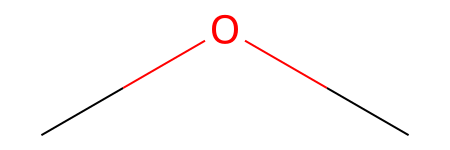

In [22]:
import networkx as nx
from rdkit import Chem

def nx_to_rdkit(graph):
    # Créer une molécule vide avec RDKit
    mol = Chem.RWMol()

    # Dictionnaire pour conserver une correspondance entre les nœuds de NetworkX et les atomes de RDKit
    node_to_atom = {}

    # Ajouter les atomes
    for node, data in graph.nodes(data=True):
        atom = Chem.Atom(data['atom_symbol'])
        atom_idx = mol.AddAtom(atom)
        node_to_atom[node] = atom_idx

    # Ajouter les liaisons
    for u, v, data in graph.edges(data=True):
        start_idx = node_to_atom[u]
        end_idx = node_to_atom[v]
        bond_type = data['bond_type']
        #print(bond_type, data['edge_attr'])
        mol.AddBond(start_idx, end_idx, bond_type)

    # Convertir en molécule finale et retourner
    return mol.GetMol()
mol = nx_to_rdkit(graphs[0])
mol

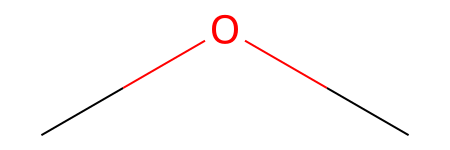

In [23]:
from rdkit.Chem import AllChem

mol = nx_to_rdkit(graphs[0])
mol


In [24]:
from rdkit.Chem import SanitizeMol

mol.UpdatePropertyCache()
SanitizeMol(mol)
# Calculer le Morgan fingerprint
fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=1024)
# Convertir le fingerprint en numpy.array
fp_array = np.array(list(fp))

# Afficher le fingerprint   
print(fp_array)


[0 0 0 ... 0 0 0]


In [25]:

from rdkit.Chem.MolStandardize import rdMolStandardize 
from rdkit.Chem import Descriptors

def mol_to_fp(mol):


    mol.UpdatePropertyCache()
    SanitizeMol(mol)
    # Calculer le Morgan fingerprint
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=1024)
    # Convertir le fingerprint en numpy.array
    fp_array = np.array(list(fp))

    # Afficher le fingerprint  
    return fp_array

print(mol_to_fp(mol))

[0 0 0 ... 0 0 0]


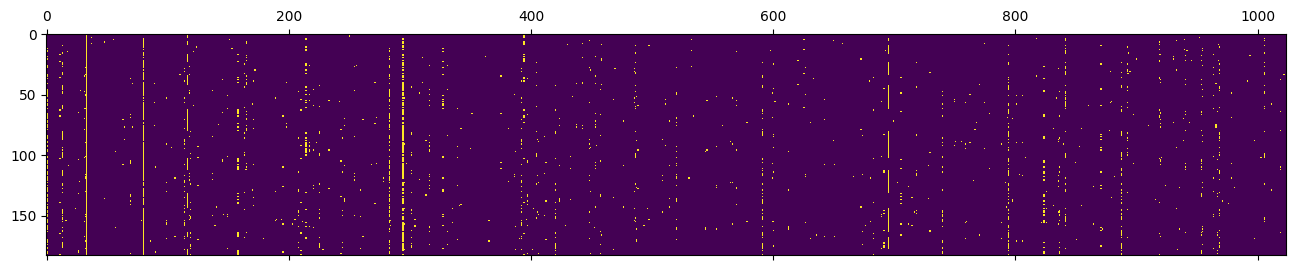

In [26]:
embeddings = np.array([mol_to_fp(nx_to_rdkit(g)) for g in graphs])
plt.matshow(embeddings)
plt.show()

In [27]:
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

for _ in range(10):
    X_train, X_test, y_train, y_test = train_test_split(embeddings, y, test_size=0.2)

    parameters = {'kernel':('linear', 'rbf'), 'C':np.logspace(-1,4,20), 'epsilon':np.logspace(-1,1,20)}

    svr = SVR()
    clf = GridSearchCV(svr, parameters)
    clf.fit(X_train, y_train)

    y_pred_train = clf.predict(X_train)
    y_pred_test = clf.predict(X_test)
    rmse_train = np.sqrt(np.mean((y_pred_train - y_train)**2))
    rmse_test = np.sqrt(np.mean((y_pred_test - y_test)**2))
    with (np.printoptions(precision=3, suppress=True)):
        print(f"{rmse_train=}, {rmse_test=}")

    mae_train = np.mean(np.abs(y_pred_train - y_train))
    mae_test = np.mean(np.abs(y_pred_test - y_test))
    with (np.printoptions(precision=3, suppress=True)):
        print(f"{mae_train=}, {mae_test=}") 

rmse_train=4.825190297599662, rmse_test=30.65153239465403
mae_train=1.0705885480861226, mae_test=25.84949577456413
rmse_train=14.05556462922867, rmse_test=24.775112253786098
mae_train=8.919143163570608, mae_test=19.933080602679535
rmse_train=10.655871237964307, rmse_test=26.02825137601047
mae_train=7.786923392198706, mae_test=20.232790000995212
rmse_train=5.839656111876218, rmse_test=24.72385464638686
mae_train=1.2349735765572478, mae_test=19.746388085127432
rmse_train=3.636437601743903, rmse_test=26.953785436998608
mae_train=0.698327253269183, mae_test=21.61359174526201
rmse_train=5.548049244228641, rmse_test=31.3534198492181
mae_train=1.0705785206654903, mae_test=23.939437643228494
rmse_train=5.866642571549978, rmse_test=24.85832845007993
mae_train=1.476746142865838, mae_test=20.487940798556647
rmse_train=10.15159428481786, rmse_test=24.668235371454138
mae_train=4.67859173716521, mae_test=19.375673723568795
rmse_train=5.5797980698464835, rmse_test=27.259865206667143
mae_train=1.07882